In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [5]:
!pip install yfinance
!pip install pandas numpy matplotlib seaborn
!pip install scikit-learn
!pip install tensorflow
!pip install statsmodels
!pip install joblib

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
df = pd.read_csv(
'/content/drive/MyDrive/karthik/VK/Financial-Time-Series-Analytics/Data/all_bank_stock_data.csv'
)

df.head()

,Date,Bank,Open,High,Low,Close,Volume
0,NaN,NaN,LLOY.L,LLOY.L,LLOY.L,LLOY.L,LLOY.L
1,2015-01-02,Lloyds,76.11351372005572,76.39220720232863,75.31624532740311,75.79500579833984,54277932
2,2015-01-05,Lloyds,75.71538565801829,76.04384912596093,74.11289035617187,74.27214813232422,102525515
3,2015-01-06,Lloyds,74.28209387862202,74.70014173189884,72.53030395507812,72.53030395507812,133810250
4,2015-01-07,Lloyds,72.978191980182,73.59828873371622,72.5302928555775,72.66963958740234,108980419


In [8]:
df['Date'] = pd.to_datetime(df['Date'])

numeric_cols = ['Open','High','Low','Close','Volume']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dropna(inplace=True)

encoder = LabelEncoder()
df['Bank'] = encoder.fit_transform(df['Bank'])

df = df.sort_values('Date')

In [9]:
df.to_csv('cleaned_stock_data.csv',index=False)

In [10]:
df['Lag1'] = df.groupby('Bank')['Close'].shift(1)
df['Lag2'] = df.groupby('Bank')['Close'].shift(2)
df['Lag3'] = df.groupby('Bank')['Close'].shift(3)

df['MA5'] = df.groupby('Bank')['Close'].transform(lambda s: s.rolling(5).mean())
df['MA10'] = df.groupby('Bank')['Close'].transform(lambda s: s.rolling(10).mean())

df.dropna(inplace=True)

In [11]:
df.to_csv("feature_data.csv",index=False)

In [12]:
close=df['Close']

train_size=int(len(close)*0.8)

train=close[:train_size]

test=close[train_size:]

In [13]:
from statsmodels.tsa.arima.model import ARIMA
model=ARIMA(train,order=(5,1,0))

model_fit=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [14]:
forecast=model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [15]:
arima_mae=mean_absolute_error(test,forecast)

arima_rmse=np.sqrt(mean_squared_error(test,forecast))

arima_r2=r2_score(test,forecast)

#: Random Forest


In [16]:
X_rf = df[['Bank','Open','High','Low','Volume','Lag1','Lag2','Lag3','MA5','MA10']]

y_rf = df['Close']

In [17]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf,
    y_rf,
    test_size=0.2,
    shuffle=False
)

In [18]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [19]:
!pip install scikit-learn

## Hyperparameter Tuning (Random Forest)

In [20]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV

# TimeSeriesSplit instead of default KFold — regular CV would shuffle rows and let
# the model validate on data that comes BEFORE some of its training data (leakage).
rf_param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 1.0],
}

rf_tscv = TimeSeriesSplit(n_splits=5)

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=rf_tscv,
    random_state=42,
    n_jobs=-1,
)

rf_search.fit(X_train_rf, y_train_rf)

print("Best Random Forest params:", rf_search.best_params_)
print("Best CV MAE:", -rf_search.best_score_)

Best Random Forest params: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': None}
Best CV MAE: 4.145233897716794


In [21]:
rf = rf_search.best_estimator_

rf.fit(X_train_rf, y_train_rf)

rf_pred = rf.predict(X_test_rf)

In [22]:
rf_mae = mean_absolute_error(y_test_rf, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test_rf, rf_pred))

rf_r2 = r2_score(y_test_rf, rf_pred)

print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

MAE : 92.60428613455471
RMSE: 183.38964022989953
R²  : 0.49802603745017116


# LSTM

In [23]:
sequence = 60

# Fit one scaler PER BANK — Goldman Sachs, Barclays, and Lloyds trade on very
# different price scales, so a single global scaler would distort all three.
bank_scalers = {}
bank_scaled_close = {}

for bank_id in sorted(df['Bank'].unique()):
    bank_close = df.loc[df['Bank'] == bank_id].sort_values('Date')[['Close']]

    scaler = MinMaxScaler()
    bank_scaled_close[bank_id] = scaler.fit_transform(bank_close)
    bank_scalers[bank_id] = scaler

In [24]:
bank_sequences = {}  # bank_id -> (X_bank, y_bank)

for bank_id, scaled in bank_scaled_close.items():
    X_bank, y_bank = [], []

    for i in range(sequence, len(scaled)):
        X_bank.append(scaled[i-sequence:i, 0])
        y_bank.append(scaled[i, 0])

    bank_sequences[bank_id] = (np.array(X_bank), np.array(y_bank))

In [25]:
X_train_parts, X_test_parts = [], []
y_train_parts, y_test_parts = [], []
test_bank_ids = []  # remembers which bank each TEST row belongs to, for inverse-scaling later

for bank_id, (X_bank, y_bank) in bank_sequences.items():
    split = int(len(X_bank) * 0.8)

    X_train_parts.append(X_bank[:split])
    X_test_parts.append(X_bank[split:])

    y_train_parts.append(y_bank[:split])
    y_test_parts.append(y_bank[split:])

    test_bank_ids.extend([bank_id] * (len(X_bank) - split))

X_train_lstm = np.concatenate(X_train_parts).reshape(-1, sequence, 1)
X_test_lstm = np.concatenate(X_test_parts).reshape(-1, sequence, 1)

y_train_lstm = np.concatenate(y_train_parts)
y_test_lstm = np.concatenate(y_test_parts)

test_bank_ids = np.array(test_bank_ids)

## Hyperparameter Tuning (LSTM)

In [26]:
from tensorflow.keras.optimizers import Adam

# Hold out the LAST 15% of the training sequences as a validation set for tuning,
# so X_test_lstm stays completely unseen until the final chosen model is evaluated.
val_split = int(len(X_train_lstm) * 0.85)

X_tr, X_val = X_train_lstm[:val_split], X_train_lstm[val_split:]
y_tr, y_val = y_train_lstm[:val_split], y_train_lstm[val_split:]

lstm_configs = [
    {"units": 32,  "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
    {"units": 64,  "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
    {"units": 64,  "dropout": 0.3, "batch_size": 16, "learning_rate": 0.0005},
    {"units": 100, "dropout": 0.2, "batch_size": 32, "learning_rate": 0.001},
]

def build_lstm(units, dropout, learning_rate):
    m = Sequential()
    m.add(LSTM(units, return_sequences=True, input_shape=(sequence, 1)))
    m.add(Dropout(dropout))
    m.add(LSTM(units))
    m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return m

lstm_tuning_results = []

for cfg in lstm_configs:
    tuning_model = build_lstm(cfg["units"], cfg["dropout"], cfg["learning_rate"])

    tuning_history = tuning_model.fit(
        X_tr, y_tr,
        epochs=15,
        batch_size=cfg["batch_size"],
        validation_data=(X_val, y_val),
        verbose=0,
    )

    val_loss = min(tuning_history.history["val_loss"])
    lstm_tuning_results.append({**cfg, "val_loss": val_loss})
    print(cfg, "-> val_loss:", val_loss)

lstm_tuning_df = pd.DataFrame(lstm_tuning_results).sort_values("val_loss").reset_index(drop=True)
lstm_tuning_df

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


{'units': 32, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00025997651391662657
{'units': 64, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00020997057436034083
{'units': 64, 'dropout': 0.3, 'batch_size': 16, 'learning_rate': 0.0005} -> val_loss: 0.0002213114348705858
{'units': 100, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00018906807235907763


,units,dropout,batch_size,learning_rate,val_loss
0,100,0.2,32,0.0010,0.000189
1,64,0.2,32,0.0010,0.000210
2,64,0.3,16,0.0005,0.000221
3,32,0.2,32,0.0010,0.000260


In [27]:
best_lstm_config = lstm_tuning_df.iloc[0].to_dict()
print("Best LSTM config:", best_lstm_config)

model = build_lstm(
    int(best_lstm_config["units"]),
    best_lstm_config["dropout"],
    best_lstm_config["learning_rate"],
)

history = model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=int(best_lstm_config["batch_size"]),
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1,
)

Best LSTM config: {'units': 100.0, 'dropout': 0.2, 'batch_size': 32.0, 'learning_rate': 0.001, 'val_loss': 0.00018906807235907763}
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.0021 - val_loss: 9.6573e-04
Epoch 2/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.7278e-04 - val_loss: 6.7303e-04
Epoch 3/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.5100e-04 - val_loss: 0.0011
Epoch 4/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 4.8231e-04 - val_loss: 5.4295e-04
Epoch 5/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 4.7260e-04 - val_loss: 5.5001e-04
Epoch 6/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.9991e-04 - val_loss: 4.8464e-04
Epoch 7/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 3.7005e-04 - val_loss: 5.6281e-04
Epoch 8/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.5670e-04 - val_loss: 6.3907e-04
Epoch 9/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.2934e-04 - val_loss: 3.6808e-04
Epoch 10/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 3.0078e-04 - val_loss: 7.0616e-04
Epoch 11/30
211/211 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 2.9896

In [28]:
lstm_pred_scaled = model.predict(X_test_lstm)

lstm_pred_parts, actual_parts = [], []

for bank_id in sorted(set(test_bank_ids)):
    mask = test_bank_ids == bank_id
    scaler = bank_scalers[bank_id]

    lstm_pred_parts.append(scaler.inverse_transform(lstm_pred_scaled[mask]))
    actual_parts.append(scaler.inverse_transform(y_test_lstm[mask].reshape(-1, 1)))

lstm_pred = np.concatenate(lstm_pred_parts)
actual = np.concatenate(actual_parts)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


In [29]:
lstm_mae=mean_absolute_error(actual,lstm_pred)

lstm_rmse=np.sqrt(mean_squared_error(actual,lstm_pred))

lstm_r2=r2_score(actual,lstm_pred)

#Model Comparison

In [30]:
comparison=pd.DataFrame({

'Model':['ARIMA','Random Forest','LSTM'],

'MAE':[arima_mae,rf_mae,lstm_mae],

'RMSE':[arima_rmse,rf_rmse,lstm_rmse],

'R2 Score':[arima_r2,rf_r2,lstm_r2]

})

comparison

,Model,MAE,RMSE,R2 Score
0,ARIMA,219.499007,279.699850,-0.167659
1,Random Forest,92.604286,183.389640,0.498026
2,LSTM,10.277385,16.282658,0.996072


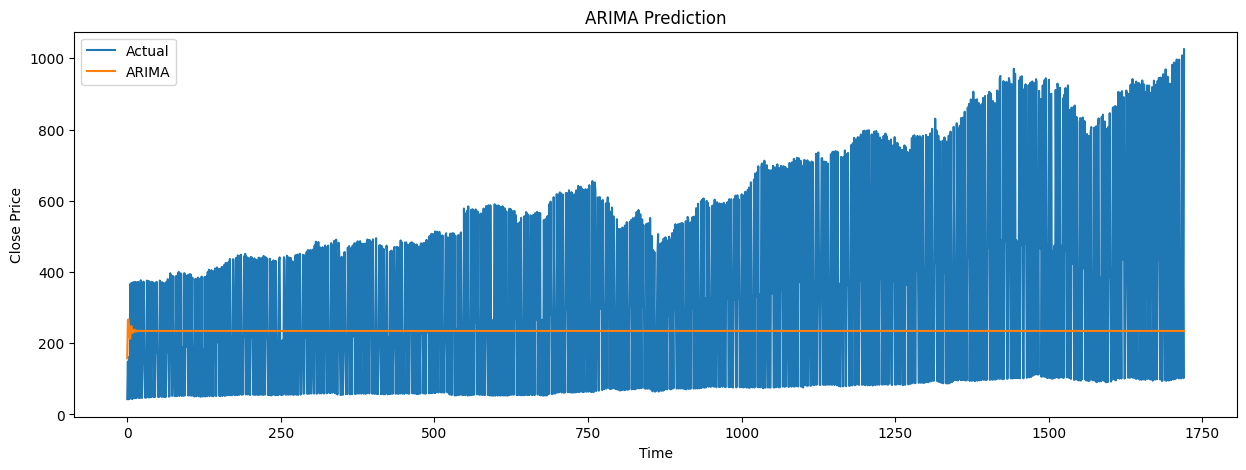

In [31]:
plt.figure(figsize=(15,5))

plt.plot(test.values,label='Actual')

plt.plot(forecast.values,label='ARIMA')

plt.title("ARIMA Prediction")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.show()

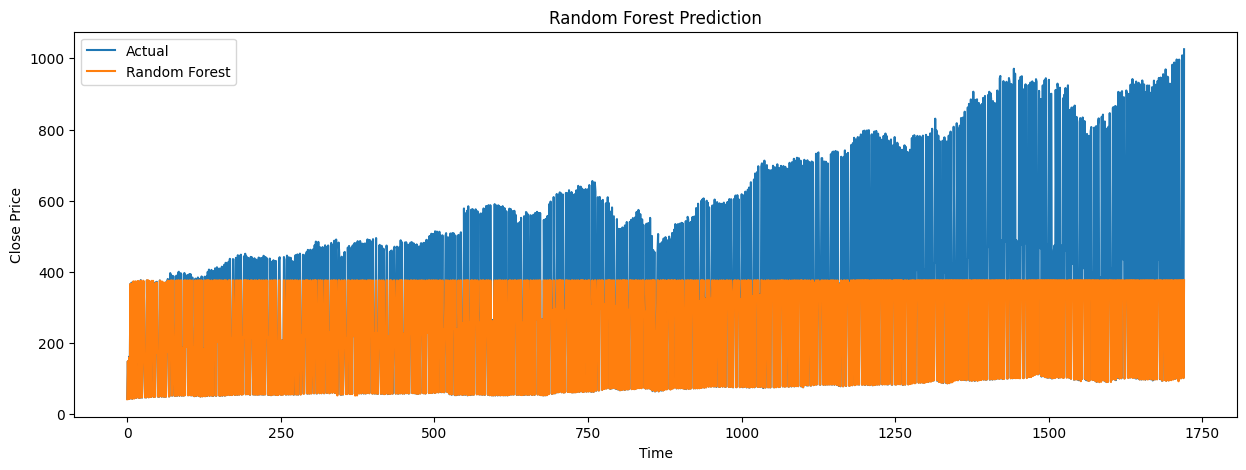

In [32]:
plt.figure(figsize=(15,5))

plt.plot(np.array(y_test_rf), label='Actual')

plt.plot(rf_pred,label='Random Forest')

plt.title("Random Forest Prediction")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.show()

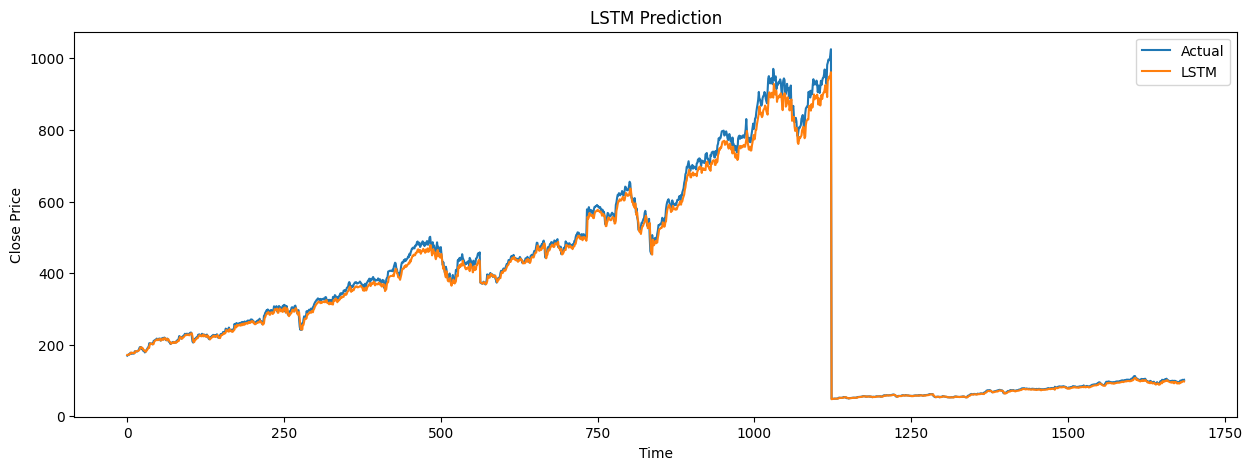

In [33]:
plt.figure(figsize=(15,5))

plt.plot(actual,label='Actual')

plt.plot(lstm_pred,label='LSTM')

plt.title("LSTM Prediction")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.legend()

plt.show()

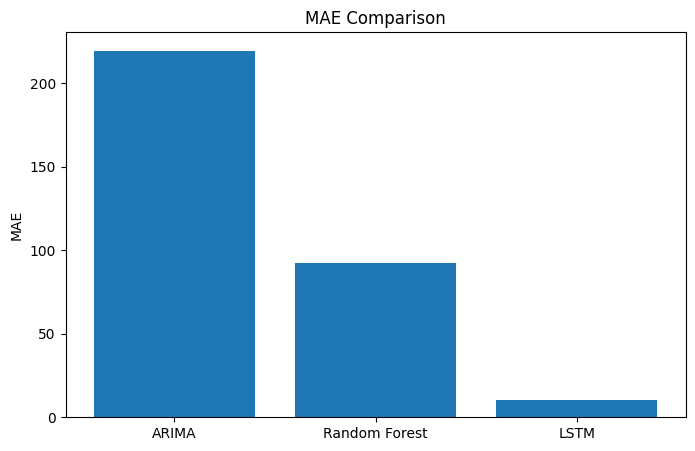

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['MAE']
)

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.show()

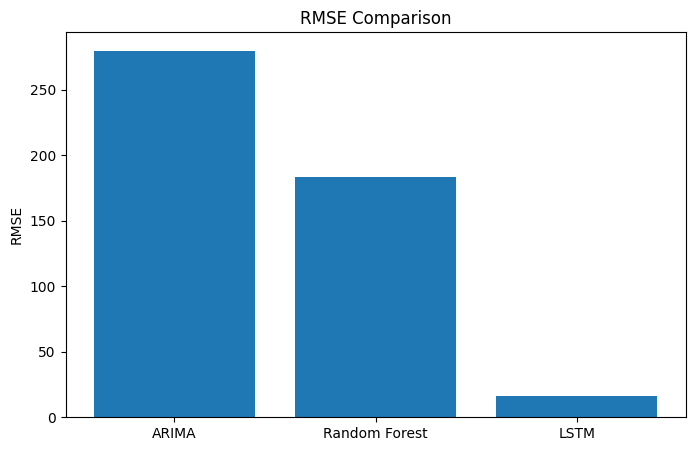

In [35]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['RMSE']
)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.show()

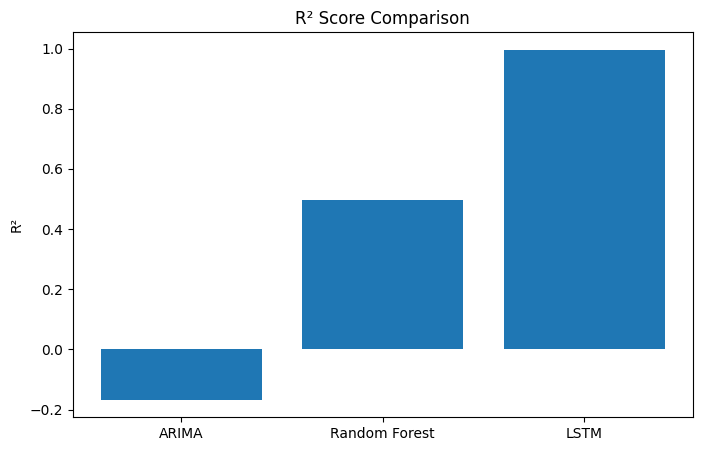

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['R2 Score']
)

plt.title("R² Score Comparison")

plt.ylabel("R²")

plt.show()

#Feature Importance (Random Forest)

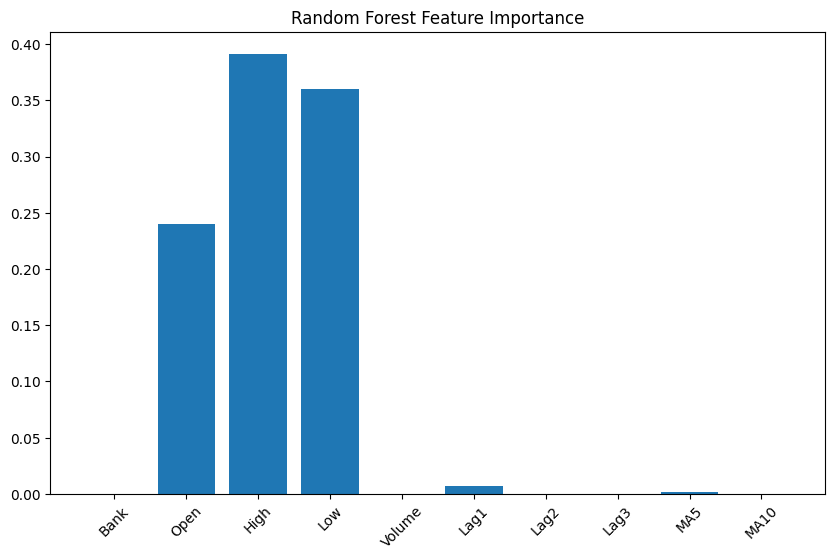

In [37]:
feature_names = [
    'Bank',
    'Open',
    'High',
    'Low',
    'Volume',
    'Lag1',
    'Lag2',
    'Lag3',
    'MA5',
    'MA10'
]

importance = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.bar(feature_names, importance)
plt.xticks(rotation=45)
plt.title("Random Forest Feature Importance")
plt.show()

#LSTM Training Loss

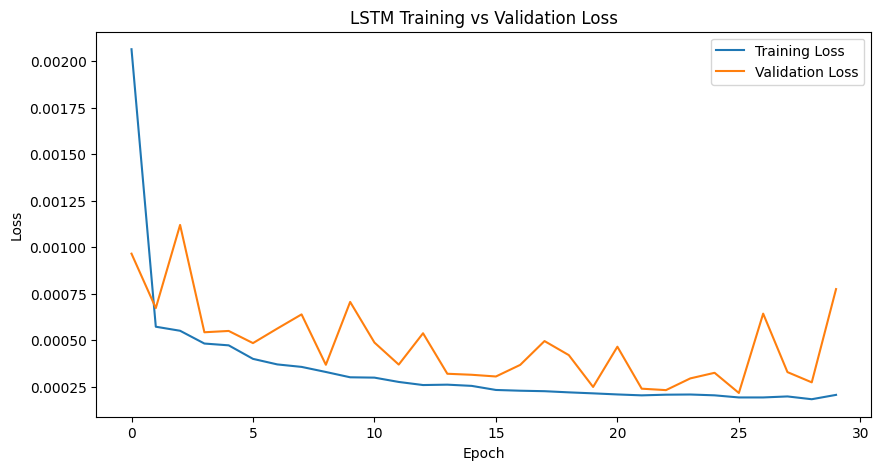

In [38]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

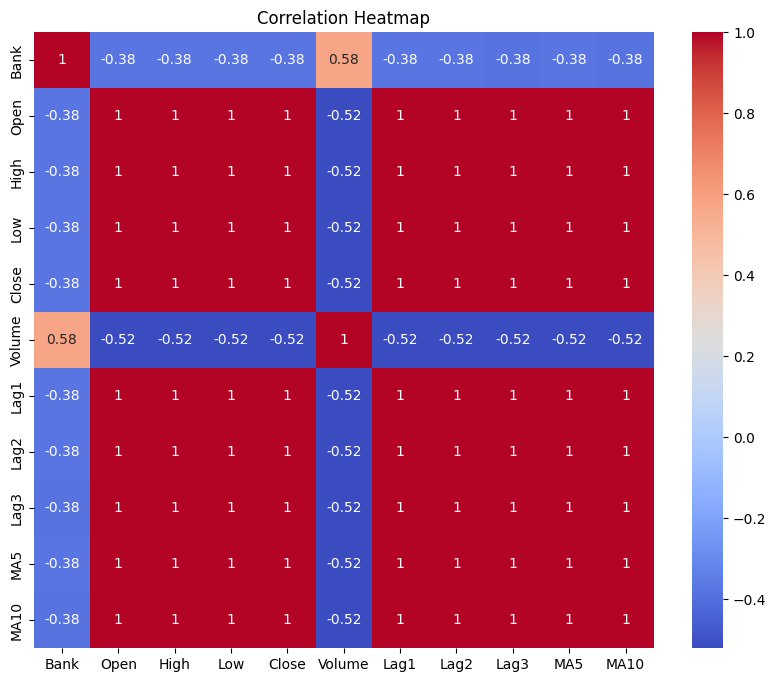

In [39]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

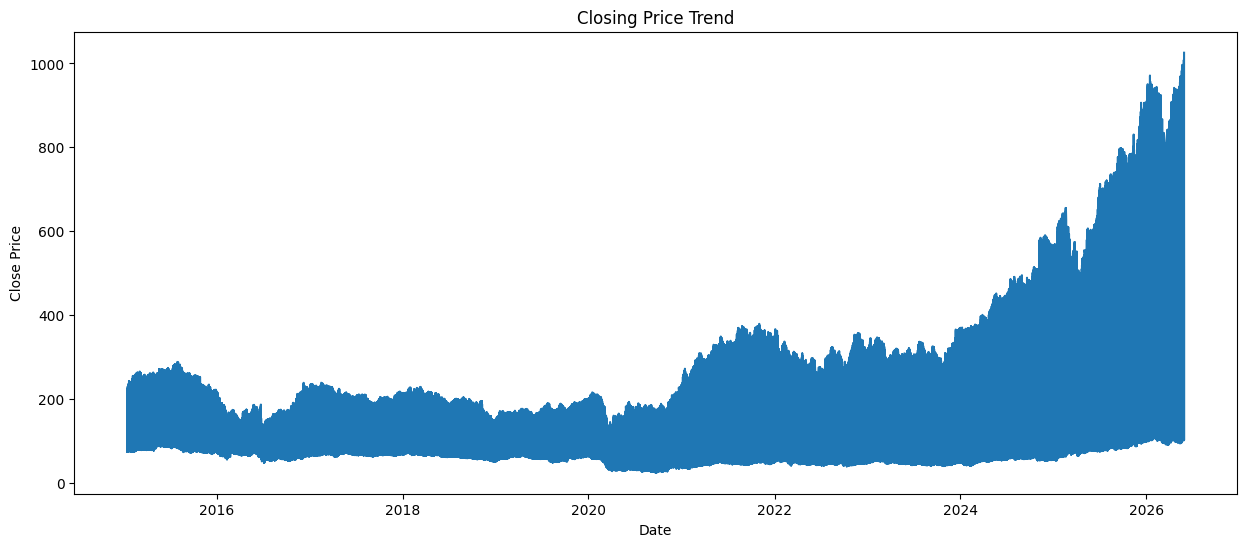

In [40]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'],df['Close'])

plt.title("Closing Price Trend")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()

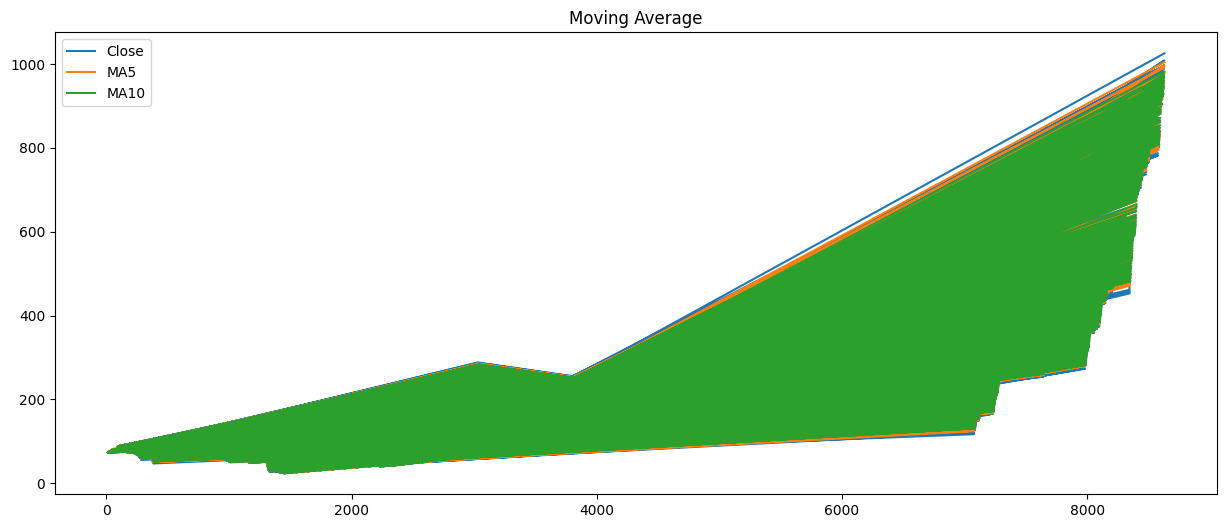

In [41]:
plt.figure(figsize=(15,6))

plt.plot(df['Close'],label='Close')

plt.plot(df['MA5'],label='MA5')

plt.plot(df['MA10'],label='MA10')

plt.legend()

plt.title("Moving Average")

plt.show()

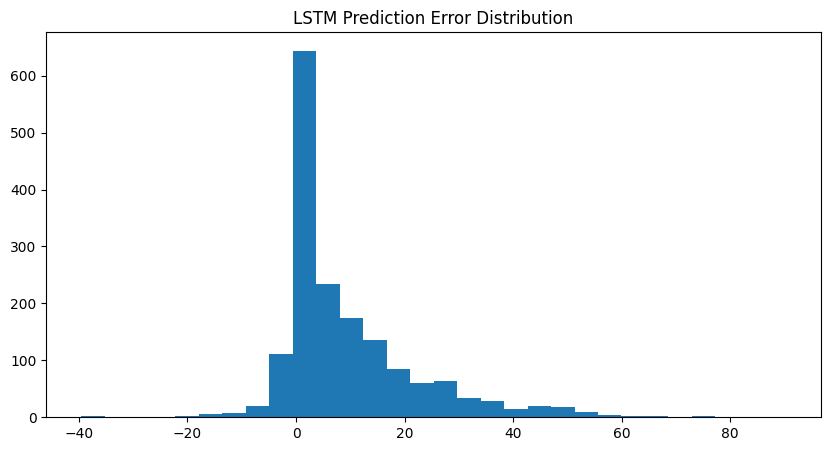

In [42]:
error = actual.flatten()-lstm_pred.flatten()

plt.figure(figsize=(10,5))

plt.hist(error,bins=30)

plt.title("LSTM Prediction Error Distribution")

plt.show()

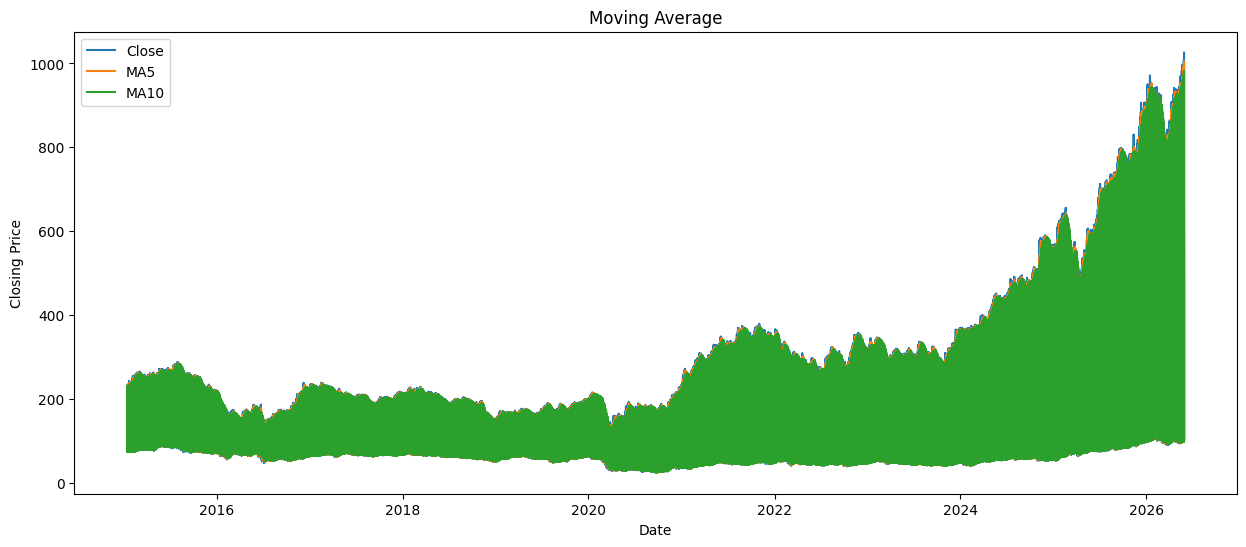

In [43]:
plt.figure(figsize=(15,6))

plt.plot(df['Date'], df['Close'], label='Close')
plt.plot(df['Date'], df['MA5'], label='MA5')
plt.plot(df['Date'], df['MA10'], label='MA10')

plt.title("Moving Average")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()

plt.show()

In [44]:
bank_df = df[df['Bank'] == 0]   # Replace 0 with the encoded bank you want

In [45]:
!pip install statsmodels
!pip install tensorflow
!pip install scikit-learn
!pip install yfinance

import numpy as np
import pandas as pd
...

Ellipsis

# Stock Price Prediction using
ARIMA, Random Forest and LSTM

## Introduction

## Dataset

## Data Preprocessing

## Feature Engineering

## ARIMA Model

## Random Forest

## LSTM

## Model Comparison

## Conclusion

In [46]:
print(df.head())

print(df.shape)

print(df.info())

print(df.describe())

           Date  Bank        Open        High         Low       Close  \
2892 2015-01-15     0  226.787100  228.531617  218.856038  227.235687   
10   2015-01-15     2   72.739305   73.834175   71.594665   73.834175   
5773 2015-01-15     1  144.169166  145.305375  142.024798  142.816940   
2893 2015-01-16     0  226.089230  226.431158  222.650046  223.646912   
11   2015-01-16     2   73.286735   74.321888   72.927418   74.092964   

           Volume        Lag1        Lag2        Lag3         MA5        MA10  
2892   56132853.0  222.849472  232.269867  230.674866  228.661212  231.547131  
10    122202372.0   72.560143   73.664986   73.227020   73.336511   73.570422  
5773    3146000.0  144.209213  147.969894  148.081848  146.596808  148.898018  
2893   43987461.0  227.235687  222.849472  232.269867  227.335361  229.673026  
11    111260890.0   73.834175   72.560143   73.664986   73.475858   73.400217  
(8602, 12)
<class 'pandas.core.frame.DataFrame'>
Index: 8602 entries, 2892 to 863

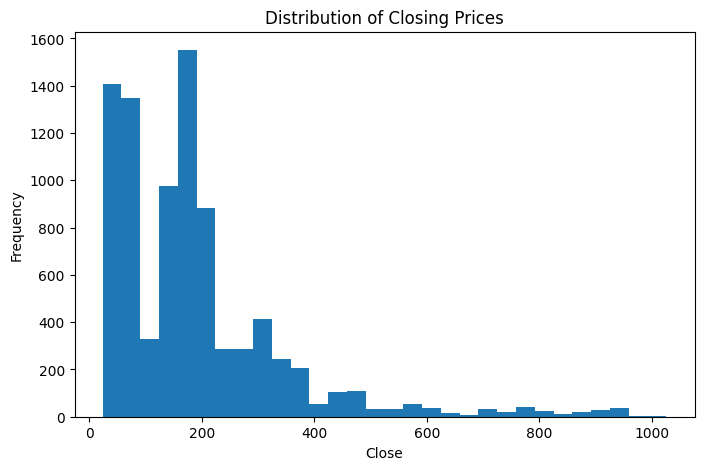

In [47]:
plt.figure(figsize=(8,5))
plt.hist(df['Close'], bins=30)
plt.title("Distribution of Closing Prices")
plt.xlabel("Close")
plt.ylabel("Frequency")
plt.show()

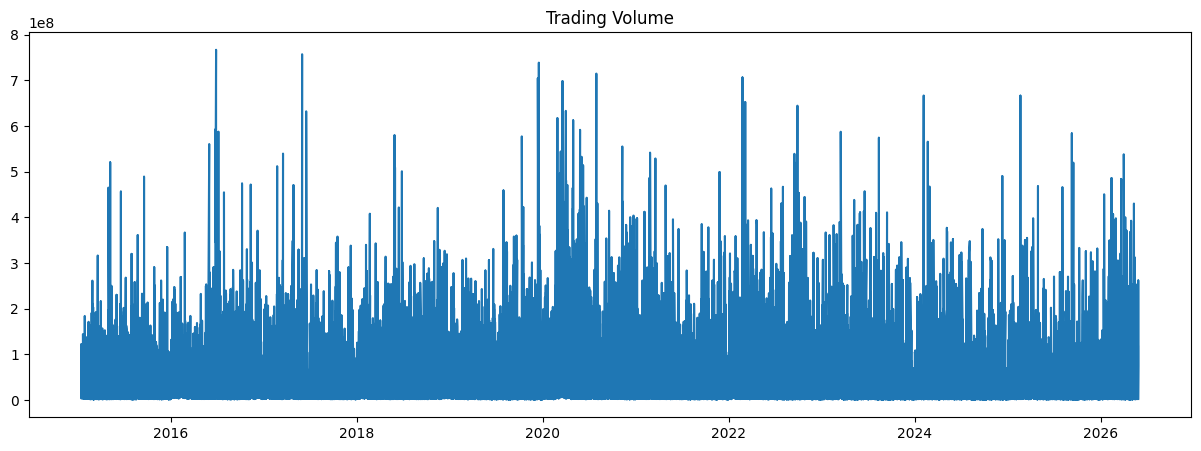

In [48]:
plt.figure(figsize=(15,5))

plt.plot(df['Date'], df['Volume'])

plt.title("Trading Volume")

plt.show()

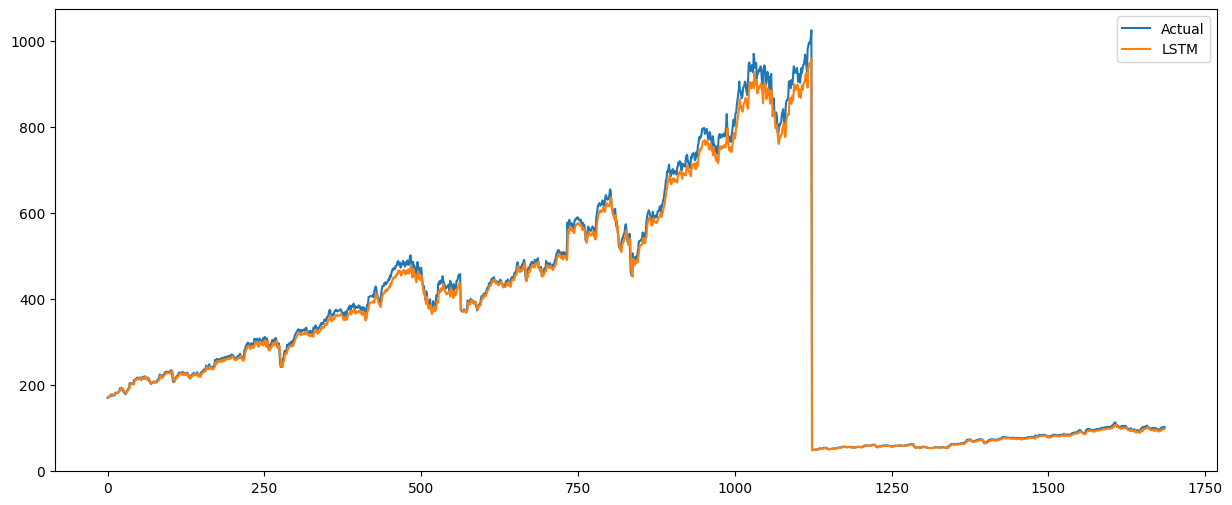

In [49]:
plt.figure(figsize=(15,6))

plt.plot(actual.flatten(), label='Actual')

plt.plot(lstm_pred.flatten(), label='LSTM')

plt.legend()

plt.show()

In [50]:
import joblib

joblib.dump(rf,'RandomForest.pkl')

['RandomForest.pkl']

In [51]:
model.save("LSTM.keras")

Conclusion

Three machine learning models were implemented for stock price prediction:
ARIMA, Random Forest, and LSTM.

Performance was evaluated using MAE, RMSE, and R² Score.

The model with the highest R² and lowest MAE/RMSE was selected as the best-performing model.

LSTM demonstrated superior capability in learning temporal dependencies, while Random Forest effectively modeled nonlinear relationships. ARIMA provided a strong statistical baseline for comparison.